In [2]:
import pandas as pd
import random
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
from datasets import Dataset
import matplotlib.pyplot as plt

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything(42)

d:\ai__course\ai_course\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_parquet('../src/data/preprocessed_data/full_data.parquet', columns=['movieId', 'userId', 'rating'])
df

,movieId,userId,rating
0,1,1,4.0
1,1,5,4.0
2,1,7,4.5
3,1,15,2.5
4,1,17,4.5
...,...,...,...
100831,193581,184,4.0
100832,193583,184,3.5
100833,193585,184,3.5
100834,193587,184,3.5


In [ ]:
train_temp, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_temp, test_size=0.176, random_state=42)

user2idx = {uid: i for i, uid in enumerate(train_df['userId'].unique())}
movie2idx = {mid: i for i, mid in enumerate(train_df['movieId'].unique())}

def encode(df, u_map, m_map):
    df = df.copy()
    df['user_idx'] = df['userId'].map(u_map)
    df['movie_idx'] = df['movieId'].map(m_map)
    df = df.dropna(subset=['user_idx', 'movie_idx'])
    df['user_idx'] = df['user_idx'].astype(int)
    df['movie_idx'] = df['movie_idx'].astype(int)
    return df[['user_idx', 'movie_idx', 'rating']]

train_enc = encode(train_df, user2idx, movie2idx)
val_enc = encode(val_df, user2idx, movie2idx)
test_enc = encode(test_df, user2idx, movie2idx)


users = torch.tensor(train_enc['user_idx'].values, dtype=torch.long)
movies = torch.tensor(train_enc['movie_idx'].values, dtype=torch.long)
ratings = torch.tensor(train_enc['rating'].values, dtype=torch.float32)

train_dataset = TensorDataset(users, movies, ratings)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

users_val = torch.tensor(val_enc['user_idx'].values, dtype=torch.long)
movies_val = torch.tensor(val_enc['movie_idx'].values, dtype=torch.long)
ratings_val = torch.tensor(val_enc['rating'].values, dtype=torch.float32)

val_dataset = TensorDataset(users_val, movies_val, ratings_val)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 276, Val batches: 57


In [ ]:
import torch.nn as nn

class SVD(nn.Module):
    def __init__(self, n_users, n_movies, n_factors=50):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, n_factors)
        self.movie_emb = nn.Embedding(n_movies, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.movie_emb.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
    
    def forward(self, user, movie):
        pred = self.global_bias
        pred = pred + self.user_bias(user) + self.movie_bias(movie)
        pred = pred + (self.user_emb(user) * self.movie_emb(movie)).sum(1, keepdim=True)
        return pred.squeeze()
n_users = train_enc['user_idx'].nunique()
n_movies = train_enc['movie_idx'].nunique() 
n_factors = 50
svd_first_model = SVD(n_users, n_movies, n_factors)
svd_first_model.to(device=DEVICE)

SVD(
  (user_emb): Embedding(610, 50)
  (movie_emb): Embedding(8543, 50)
  (user_bias): Embedding(610, 1)
  (movie_bias): Embedding(8543, 1)
)

In [ ]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: int = 0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score < self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def plot_training_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_rmse'], label='Train RMSE')
    plt.plot(history['val_rmse'], label='Val RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
def train_svd(model, train_loader, val_loader, epochs=30, lr=0.005, patience=5):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    early_stopping = EarlyStopping(patience=patience, min_delta=0)
    
    history = {'train_rmse': [], 'val_rmse': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for u, m, r in train_loader:
            u, m, r = u.to(device), m.to(device), r.to(device)
            optimizer.zero_grad()
            loss = criterion(model(u, m), r)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(u)
        
        train_rmse = (train_loss / len(train_loader.dataset)) ** 0.5
        history['train_rmse'].append(train_rmse)
 
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for u, m, r in val_loader:
                u, m, r = u.to(device), m.to(device), r.to(device)
                val_loss += criterion(model(u, m), r).item() * len(u)
        
        val_rmse = (val_loss / len(val_loader.dataset)) ** 0.5
        history['val_rmse'].append(val_rmse)

        print(f"Epoch {epoch+1:2d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

        if early_stopping.step(val_rmse, model):
            print(f"Early stop at epoch {epoch+1}")
            early_stopping.restore_best(model)
            break
    
    return model, history, early_stopping.best_score

Epoch  1 | Train RMSE: 2.5315 | Val RMSE: 1.2125
Epoch  2 | Train RMSE: 0.9450 | Val RMSE: 0.9256
Epoch  3 | Train RMSE: 0.7161 | Val RMSE: 0.9149
Epoch  4 | Train RMSE: 0.5724 | Val RMSE: 0.9320
Epoch  5 | Train RMSE: 0.4664 | Val RMSE: 0.9532
Epoch  6 | Train RMSE: 0.3961 | Val RMSE: 0.9718
Epoch  7 | Train RMSE: 0.3498 | Val RMSE: 0.9854
Epoch  8 | Train RMSE: 0.3178 | Val RMSE: 0.9965
Early stop at epoch 8


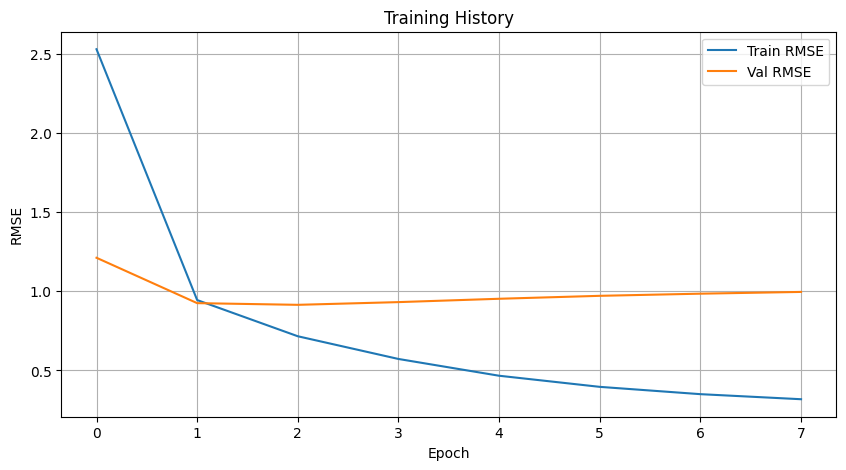

In [ ]:
first_model, history_first, best_rmse_first = train_svd(
    model=svd_first_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.005,
    patience=5
)
plot_training_history(history_first)

In [ ]:
df_full = pd.read_parquet('../src/data/preprocessed_data/full_data.parquet')
genre_columns = [col for col in df_full.columns if col.startswith('genre_')]
genres_enc_df = (
    df_full[['movieId'] + genre_columns]
    .drop_duplicates('movieId')
    .set_index('movieId')
)
genres_enc_df

,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
movieId,,,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193581,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
193583,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
193585,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
n_movies = len(movie2idx)
n_genres = len(genre_columns)
idx2movie = {v: k for k, v in movie2idx.items()}
movie_genres_tensor = torch.zeros(n_movies, n_genres, dtype=torch.float32)

for movie_idx, movie_id in idx2movie.items():
    if movie_id in genres_enc_df.index:
        movie_genres_tensor[movie_idx] = torch.tensor(
            genres_enc_df.loc[movie_id].values, dtype=torch.float32
        )


In [ ]:
class HybridSVD(nn.Module):
    def __init__(self, n_users, n_movies, n_genres, n_factors=50):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, n_factors)
        self.movie_emb = nn.Embedding(n_movies, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
    
        self.genre_layer = nn.Linear(n_genres, n_factors)
        
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.movie_emb.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
    
    def forward(self, user, movie, genres):
        pred = self.global_bias + self.user_bias(user) + self.movie_bias(movie)
        pred += (self.user_emb(user) * self.movie_emb(movie)).sum(1, keepdim=True)

        genre_effect = self.genre_layer(genres)
        pred += (self.user_emb(user) * genre_effect).sum(1, keepdim=True)
        
        return pred.squeeze()

hybrid_model = HybridSVD(n_users, n_movies, n_genres, n_factors=50)
hybrid_model = hybrid_model.to(DEVICE)

In [ ]:
def train_hybrid(model, train_loader, val_loader, movie_genres_tensor, 
                 epochs=30, lr=0.005, patience=5):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    early_stopping = EarlyStopping(patience=patience, min_delta=0)
    
    history = {'train_rmse': [], 'val_rmse': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for u, m, r in train_loader:
            u, m, r = u.to(device), m.to(device), r.to(device)
            genres = movie_genres_tensor[m].to(device)
            
            optimizer.zero_grad()
            loss = criterion(model(u, m, genres), r)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(u)
        
        train_rmse = (train_loss / len(train_loader.dataset)) ** 0.5
        history['train_rmse'].append(train_rmse)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for u, m, r in val_loader:
                u, m, r = u.to(device), m.to(device), r.to(device)
                genres = movie_genres_tensor[m].to(device)
                val_loss += criterion(model(u, m, genres), r).item() * len(u)
        
        val_rmse = (val_loss / len(val_loader.dataset)) ** 0.5
        history['val_rmse'].append(val_rmse)

        print(f"Epoch {epoch+1:2d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")

        if early_stopping.step(val_rmse, model):
            print(f"Early stop at epoch {epoch+1}")
            early_stopping.restore_best(model)
            break
    
    return model, history, early_stopping.best_score

Epoch  1 | Train RMSE: 1.4183 | Val RMSE: 0.8969
Epoch  2 | Train RMSE: 0.8114 | Val RMSE: 0.8860
Epoch  3 | Train RMSE: 0.7102 | Val RMSE: 0.8838
Epoch  4 | Train RMSE: 0.6101 | Val RMSE: 0.8880
Epoch  5 | Train RMSE: 0.5213 | Val RMSE: 0.9061
Epoch  6 | Train RMSE: 0.4521 | Val RMSE: 0.9160
Epoch  7 | Train RMSE: 0.4015 | Val RMSE: 0.9264
Epoch  8 | Train RMSE: 0.3626 | Val RMSE: 0.9363
Early stop at epoch 8


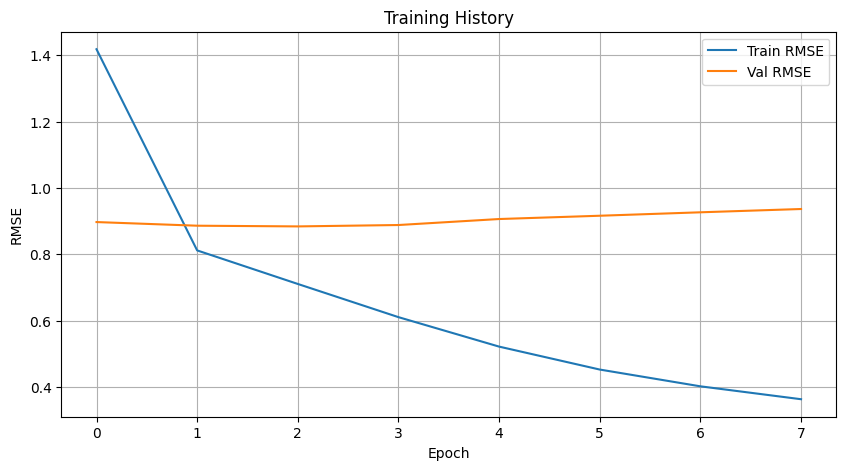

In [ ]:
sec_model, history_sec, best_rmse_sec = train_hybrid(
    model=hybrid_model,
    train_loader=train_loader,
    val_loader=val_loader,
    movie_genres_tensor=movie_genres_tensor,
    epochs=30,
    lr=0.005,
    patience=5
)
plot_training_history(history_sec)

In [ ]:
def evaluate_svd(model, val_loader, device=DEVICE):
    model.eval()
    model = model.to(device)
    
    criterion = nn.MSELoss()
    total_loss = 0
    total_samples = 0
    
    with torch.no_grad():
        for u, m, r in val_loader:
            u, m, r = u.to(device), m.to(device), r.to(device)
            
            if isinstance(model, HybridSVD):
                genres = movie_genres_tensor[m].to(device)
                preds = model(u, m, genres)
            else:
                preds = model(u, m)
            
            loss = criterion(preds, r)
            total_loss += loss.item() * len(u)
            total_samples += len(u)
    
    rmse = (total_loss / total_samples) ** 0.5
    print(f"Validation RMSE: {rmse:.4f}")
    return {'RMSE': rmse}


def evaluate_recommendations(model, val_df, user2idx, movie2idx, k=10, max_users=50, device=DEVICE):
    model.eval()
    model = model.to(device)
    
    idx2movie = {v: k for k, v in movie2idx.items()}

    valid_users = [u for u in val_df['userId'].unique() if u in user2idx]
    if len(valid_users) > max_users:
        valid_users = valid_users[:max_users] 
    
    
    precisions = []
    recalls = []
    ndcgs = []
    
    for user_id in valid_users:

        good_movies = val_df[(val_df['userId'] == user_id) & (val_df['rating'] >= 4.0)]['movieId'].tolist()
        good_movies = [m for m in good_movies if m in movie2idx] 
        
        if len(good_movies) == 0:
            continue
    
        user_idx = torch.tensor([user2idx[user_id]], device=device)
        
        predictions = []
        for movie_id, movie_idx in movie2idx.items():
            m = torch.tensor([movie_idx], device=device)
            with torch.no_grad():
                if isinstance(model, HybridSVD):
                    g = movie_genres_tensor[m].to(device)
                    score = model(user_idx, m, g).item()
                else:
                    score = model(user_idx, m).item()
            predictions.append((movie_id, score))
 
        predictions.sort(key=lambda x: x[1], reverse=True)
        recommendations = [mid for mid, _ in predictions[:k]]
        
        good_set = set(good_movies)
        rec_set = set(recommendations)
     
        hits = len(rec_set & good_set)
        precision = hits / k
        
        recall = hits / len(good_set)
    
        dcg = 0
        for i, movie in enumerate(recommendations):
            if movie in good_set:
                dcg += 1 / np.log2(i + 2)
        
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(good_movies), k)))
        ndcg = dcg / idcg if idcg > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        ndcgs.append(ndcg)

    print(f"\n результаты(на {len(precisions)} пользователях)")
    print(f"Precision@{k}: {np.mean(precisions):.4f}")
    print(f"Recall@{k}:    {np.mean(recalls):.4f}")  
    print(f"NDCG@{k}:      {np.mean(ndcgs):.4f}")  
    
    
    return {
        'precision': np.mean(precisions),
        'recall': np.mean(recalls),
        'ndcg': np.mean(ndcgs)
    }

In [ ]:
print("Оценка SVD на валидации")
evaluate_svd(first_model, val_loader)

print("Оценка рекомендаций SVD")
results_svd = evaluate_recommendations(
    first_model, 
    val_df, 
    user2idx, 
    movie2idx, 
    k=10, 
    max_users=30 
)

print("\nОценка HybridSVD модели")
evaluate_svd(hybrid_model, val_loader)

print("\nОценка рекомендаций HybridSVD")
results_hybrid = evaluate_recommendations(
    hybrid_model, 
    val_df, 
    user2idx, 
    movie2idx, 
    k=10, 
    max_users=30
)

=== Оценка SVD на валидации ===
Validation RMSE: 0.9149
=== Оценка рекомендаций SVD ===
Оцениваем на 30 пользователях...

=== РЕЗУЛЬТАТЫ (на 30 пользователях) ===
Precision@10: 0.0500
Recall@10:    0.0264
NDCG@10:      0.0512

=== Оценка HybridSVD модели ===
Validation RMSE: 0.8838

=== Оценка рекомендаций HybridSVD ===
Оцениваем на 30 пользователях...

=== РЕЗУЛЬТАТЫ (на 30 пользователях) ===
Precision@10: 0.0067
Recall@10:    0.0024
NDCG@10:      0.0053
